# 01 — Data Preparation

Convert one dataset's raw archive into the figshare-shaped layout that every downstream notebook expects:

```
Drive/Senior_Project/data/<dataset>/processed/
├── images/<image_id>.png       grayscale uint8 256x256
├── masks/<image_id>.png        binary    uint8 256x256, values {0, 255}
├── metadata.csv                one row per image
├── metadata_summary.csv        per-class summary
└── preprocessing_config.json   the exact knobs this run used
```

**To run a different dataset:** edit `DATASET` in cell 6 and re-run all cells. The notebook dispatches to the right converter via `src.preprocess_utils.get_dataset_converter`. No source-code edits needed — adding a 3rd dataset means a new branch in that dispatch, nothing here changes.

**Supported datasets (current):**
- `figshare` — 3,064 single-slice .mat samples, 233 patients (meningioma / glioma / pituitary)
- `brats2020` — 369 multi-modal glioma cases, pre-extracted 2D slices in .h5; we keep tumor-containing slices only (~13–18k), extract FLAIR modality, merge sub-region masks into binary whole-tumor

**Runtime:** any Colab runtime (no GPU needed). figshare ≈ 3–5 minutes. brats2020 ≈ 15–30 minutes (slower due to ~10× more files written to Drive).

## Cell 1 — Install dependencies

In [1]:
%pip install -q kagglehub h5py opencv-python-headless pillow numpy pandas matplotlib tqdm

## Cell 2 — Bootstrap: Drive + repo

In [2]:
import os, sys

if not os.path.exists("/content/senior_project"):
    from google.colab import userdata
    try:
        token = userdata.get("GITHUB_TOKEN")
    except Exception:
        token = None
    url = "https://github.com/salemaker47/senior_project.git"
    if token:
        url = url.replace("https://", f"https://{token}@", 1)
    os.system(f"git clone {url} /content/senior_project")
if "/content/senior_project" not in sys.path:
    sys.path.insert(0, "/content/senior_project")

from src.notebook_setup import setup_environment

DRIVE_ROOT, REPO_ROOT = setup_environment(
    repo_url="https://github.com/salemaker47/senior_project.git",
)
print(f"DRIVE_ROOT: {DRIVE_ROOT}")
print(f"REPO_ROOT:  {REPO_ROOT}")

Mounted at /content/drive
DRIVE_ROOT: /content/drive/MyDrive/Senior_Project
REPO_ROOT:  /content/senior_project


## Cell 3 — DATASET knob

**This is the only cell you edit between runs.** All dataset-specific paths, downloads, and converter options are derived from this one variable.

In [3]:
DATASET = "brats2020"   # one of: "figshare", "brats2020"

# Per-dataset converter options. Add new entries when adding a new dataset.
DATASET_CONFIG = {
    "figshare": {
        "image_size":    256,
        "normalization": "percentile",
        "convert_kwargs": {},                                 # no dataset-specific extras
    },
    "brats2020": {
        "image_size":    256,
        "normalization": "percentile",
        "convert_kwargs": {
            "modality":             "flair",                  # T1/T1ce/T2/FLAIR — pick the modality
            "keep_only_with_tumor": True,                     # match figshare's 100%-tumor character
            "min_tumor_pixels":     1,                        # threshold for "has tumor"
        },
    },
}

# Resolve dispatch (this raises if DATASET is unknown — single source of truth)
from src.preprocess_utils import get_dataset_converter
discover_fn, convert_fn, KAGGLEHUB_DATASET_ID = get_dataset_converter(DATASET)
cfg = DATASET_CONFIG[DATASET]

print(f"DATASET:             {DATASET}")
print(f"discover_fn:         {discover_fn.__name__}")
print(f"convert_fn:          {convert_fn.__name__}")
print(f"KAGGLEHUB_DATASET_ID:{KAGGLEHUB_DATASET_ID}")
print(f"image_size:          {cfg['image_size']}")
print(f"normalization:       {cfg['normalization']}")
print(f"convert_kwargs:      {cfg['convert_kwargs']}")

DATASET:             brats2020
discover_fn:         discover_brats2020_h5_files
convert_fn:          convert_brats2020_h5_to_png_record
KAGGLEHUB_DATASET_ID:awsaf49/brats2020-training-data
image_size:          256
normalization:       percentile
convert_kwargs:      {'modality': 'flair', 'keep_only_with_tumor': True, 'min_tumor_pixels': 1}


## Cell 4 — Resolve output paths

## Cell 5 — Download the raw dataset via KaggleHub

KaggleHub caches the dataset under `/root/.cache/kagglehub/` (Colab's local SSD). It's idempotent — re-running won't re-download if it's already cached. The returned path is the **raw** dataset root; we'll discover files there in the next cell.

In [4]:
from src.file_utils import dataset_paths, ensure_dir

paths = dataset_paths(DRIVE_ROOT, DATASET)

# Print all keys first so we can see exactly what dataset_paths returned
print("paths keys:", sorted(paths.keys()))
print()

# Ensure all output dirs exist (handles either naming convention)
for key in ("raw", "processed", "images", "masks",
            "raw_dir", "processed_dir", "images_dir", "masks_dir"):
    if key in paths:
        ensure_dir(paths[key])

# Helper that picks whichever name exists for a directory key
def pick_path(*names):
    for n in names:
        if n in paths:
            return paths[n]
    raise KeyError(f"none of {names} found in dataset_paths keys: {sorted(paths.keys())}")

IMAGES_DIR = pick_path("images", "images_dir")
MASKS_DIR  = pick_path("masks",  "masks_dir")
METADATA_CSV               = pick_path("metadata_csv")
METADATA_SUMMARY_CSV       = pick_path("metadata_summary_csv")
PREPROCESSING_CONFIG_JSON  = pick_path("preprocessing_config_json")

for k, v in paths.items():
    print(f"  {k}: {v}")

paths keys: ['dataset_root', 'figures_dataprep', 'images', 'masks', 'metadata_csv', 'metadata_summary_csv', 'preprocessing_config_json', 'processed', 'raw', 'splits']

  dataset_root: /content/drive/MyDrive/Senior_Project/data/brats2020
  raw: /content/drive/MyDrive/Senior_Project/data/brats2020/raw
  processed: /content/drive/MyDrive/Senior_Project/data/brats2020/processed
  images: /content/drive/MyDrive/Senior_Project/data/brats2020/processed/images
  masks: /content/drive/MyDrive/Senior_Project/data/brats2020/processed/masks
  metadata_csv: /content/drive/MyDrive/Senior_Project/data/brats2020/processed/metadata.csv
  metadata_summary_csv: /content/drive/MyDrive/Senior_Project/data/brats2020/processed/metadata_summary.csv
  preprocessing_config_json: /content/drive/MyDrive/Senior_Project/data/brats2020/processed/preprocessing_config.json
  splits: /content/drive/MyDrive/Senior_Project/data/brats2020/splits
  figures_dataprep: /content/drive/MyDrive/Senior_Project/outputs/figures/dat

In [5]:
import kagglehub
from pathlib import Path

raw_root = Path(kagglehub.dataset_download(KAGGLEHUB_DATASET_ID))
print(f"raw dataset root: {raw_root}")

# Quick look at the top-level structure
top = sorted([p.name for p in raw_root.iterdir()])
print(f"top-level entries ({len(top)}): {top[:10]}{'...' if len(top) > 10 else ''}")

100%|██████████| 6.76G/6.76G [04:38<00:00, 26.0MB/s]

Extracting files...


raw dataset root: /root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3
top-level entries (2): ['BraTS20 Training Metadata.csv', 'BraTS2020_training_data']


## Cell 6 — Discover sample files

In [6]:
sample_paths = discover_fn(raw_root)
n_candidates = len(sample_paths)
print(f"found {n_candidates:,} candidate {DATASET} files")
print(f"first 3:  {[p.name for p in sample_paths[:3]]}")
print(f"last 3:   {[p.name for p in sample_paths[-3:]]}")

# Sanity bounds per dataset
if DATASET == "figshare":
    assert n_candidates == 3064, f"expected 3,064 figshare .mat samples, found {n_candidates}"
elif DATASET == "brats2020":
    # 369 patients * 155 slices = 57,195 total
    assert 50_000 <= n_candidates <= 60_000, f"expected ~57,195 brats slices, found {n_candidates}"
print("count sanity: OK")

found 57,195 candidate brats2020 files
first 3:  ['volume_1_slice_0.h5', 'volume_1_slice_1.h5', 'volume_1_slice_2.h5']
last 3:   ['volume_369_slice_152.h5', 'volume_369_slice_153.h5', 'volume_369_slice_154.h5']
count sanity: OK


## Cell 7 — Convert raw files → PNG images + masks + metadata rows

This is the slow cell. The converter writes PNGs directly to Drive (per project instruction §11 — NB01/NB02 are outside the heavy-write training hot path).

Each `convert_fn(...)` call returns either:
- a **dict** — the metadata row (keep it)
- `None` — the file was filtered out (e.g., a brats2020 slice with no tumor pixels; figshare always returns a record)

In [7]:
from tqdm.auto import tqdm

records = []
n_skipped = 0
n_errors  = 0
errors    = []

for src_path in tqdm(sample_paths, desc=f"converting {DATASET}"):
    try:
        rec = convert_fn(
            src_path,
            image_out_dir=IMAGES_DIR,
            mask_out_dir=MASKS_DIR,
            target_size=(cfg["image_size"], cfg["image_size"]),
            normalization=cfg["normalization"],
            path_style="relative",
            project_root=DRIVE_ROOT,
            **cfg["convert_kwargs"],
        )
    except Exception as e:
        n_errors += 1
        if len(errors) < 10:
            errors.append((src_path.name, repr(e)))
        continue

    if rec is None:
        n_skipped += 1
        continue
    records.append(rec)

print(f"\nfound:    {n_candidates:,}")
print(f"kept:     {len(records):,}")
print(f"skipped:  {n_skipped:,}   (empty-tumor or filtered out)")
print(f"errors:   {n_errors}")
if errors:
    print("\nfirst errors:")
    for name, err in errors:
        print(f"  {name}: {err}")
assert n_errors == 0, "stop and inspect errors before continuing"
assert len(records) > 0, "no records produced — check the converter or DATASET"

converting brats2020:   0%|          | 0/57195 [00:00<?, ?it/s]


found:    57,195
kept:     24,422
skipped:  32,773   (empty-tumor or filtered out)
errors:   0


## Cell 8 — Write `metadata.csv`

In [8]:
import pandas as pd
from src.data_utils import REQUIRED_METADATA_COLUMNS, validate_metadata

metadata_df = pd.DataFrame.from_records(records)
print(f"metadata_df shape: {metadata_df.shape}")
print(f"columns: {list(metadata_df.columns)}")

validate_metadata(metadata_df)
print(f"\nrequired columns present: {sorted(REQUIRED_METADATA_COLUMNS)}")

metadata_df.to_csv(METADATA_CSV, index=False)
print(f"\nwrote {METADATA_CSV}")
metadata_df.head(3)

metadata_df shape: (24422, 15)
columns: ['image_id', 'patient_id', 'image_path', 'mask_path', 'tumor_class', 'tumor_class_id', 'dataset', 'source_path', 'modality', 'volume_idx', 'slice_idx', 'height', 'width', 'mask_positive_pixels', 'mask_area_ratio']

required columns present: ['dataset', 'image_id', 'image_path', 'mask_path', 'patient_id', 'tumor_class']

wrote /content/drive/MyDrive/Senior_Project/data/brats2020/processed/metadata.csv


,image_id,patient_id,image_path,mask_path,tumor_class,tumor_class_id,dataset,source_path,modality,volume_idx,slice_idx,height,width,mask_positive_pixels,mask_area_ratio
0,brats20_v001_s030,BraTS20_Training_001,data/brats2020/processed/images/brats20_v001_s...,data/brats2020/processed/masks/brats20_v001_s0...,glioma,2,brats2020,/root/.cache/kagglehub/datasets/awsaf49/brats2...,flair,1,30,256,256,4,0.000061
1,brats20_v001_s031,BraTS20_Training_001,data/brats2020/processed/images/brats20_v001_s...,data/brats2020/processed/masks/brats20_v001_s0...,glioma,2,brats2020,/root/.cache/kagglehub/datasets/awsaf49/brats2...,flair,1,31,256,256,95,0.001450
2,brats20_v001_s032,BraTS20_Training_001,data/brats2020/processed/images/brats20_v001_s...,data/brats2020/processed/masks/brats20_v001_s0...,glioma,2,brats2020,/root/.cache/kagglehub/datasets/awsaf49/brats2...,flair,1,32,256,256,227,0.003464


## Cell 9 — Write `metadata_summary.csv` (per-class summary)

In [9]:
from src.data_utils import metadata_summary

summary_df = metadata_summary(metadata_df)
summary_df.to_csv(METADATA_SUMMARY_CSV, index=False)
print(f"wrote {METADATA_SUMMARY_CSV}")
summary_df

wrote /content/drive/MyDrive/Senior_Project/data/brats2020/processed/metadata_summary.csv


,metric,value
0,num_images,24422.000000
1,num_patients,369.000000
2,class_glioma,24422.000000
3,mask_area_ratio_mean,0.026112
4,mask_area_ratio_median,0.021950


## Cell 10 — Write `preprocessing_config.json` (full provenance of this run)

In [10]:
from src.file_utils import save_json
from datetime import datetime, timezone

preprocessing_config = {
    "dataset":              DATASET,
    "kagglehub_dataset_id": KAGGLEHUB_DATASET_ID,
    "raw_root":             str(raw_root),
    "image_size":           cfg["image_size"],
    "normalization":        cfg["normalization"],
    "convert_kwargs":       cfg["convert_kwargs"],
    "n_candidates":         int(n_candidates),
    "n_kept":               int(len(records)),
    "n_skipped":            int(n_skipped),
    "n_errors":             int(n_errors),
    "generated_at":         datetime.now(timezone.utc).isoformat(),
}
save_json(preprocessing_config, PREPROCESSING_CONFIG_JSON)
print(f"wrote {PREPROCESSING_CONFIG_JSON}")
print()
for k, v in preprocessing_config.items():
    print(f"  {k}: {v}")

wrote /content/drive/MyDrive/Senior_Project/data/brats2020/processed/preprocessing_config.json

  dataset: brats2020
  kagglehub_dataset_id: awsaf49/brats2020-training-data
  raw_root: /root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3
  image_size: 256
  normalization: percentile
  convert_kwargs: {'modality': 'flair', 'keep_only_with_tumor': True, 'min_tumor_pixels': 1}
  n_candidates: 57195
  n_kept: 24422
  n_skipped: 32773
  n_errors: 0
  generated_at: 2026-05-11T19:38:00.127587+00:00


## Cell 11 — Visualize class examples (sanity check)

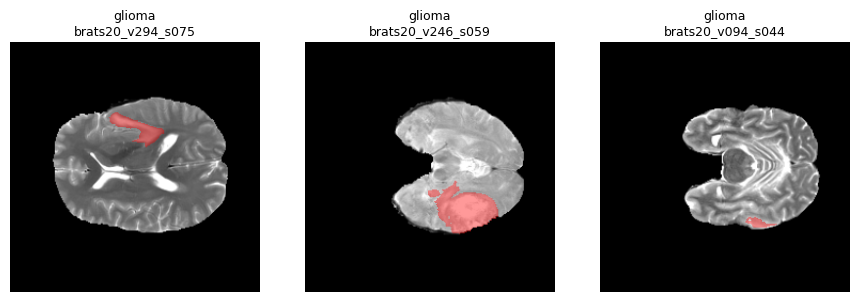

In [13]:
from src.vis_utils import show_class_examples

show_class_examples(
    metadata_df=metadata_df,
    project_root=DRIVE_ROOT,
    n_per_class=3,

)

## Done — what was produced

The processed dataset is now in Drive at:

```
Drive/Senior_Project/data/<dataset>/processed/
├── images/<image_id>.png
├── masks/<image_id>.png
├── metadata.csv
├── metadata_summary.csv
└── preprocessing_config.json
```

Next: run **`02_split.ipynb`** with the same `DATASET` to produce CV fold CSVs under `data/<dataset>/splits/{patient_level,image_level}/`.